### INSTALLATION

All required libraries with fixed versions for reproducibility.
Why: Ensures the pipeline behaves consistently across environments.

In [27]:
!pip install -q pandas==2.2.3 numpy==1.26.4 scikit-learn==1.5.2 \
imbalanced-learn==0.12.4 xgboost==2.1.3 mlflow==2.19.0 \
optuna==4.1.0 shap==0.47.0 pandera==0.23.1 \
matplotlib==3.9.4 seaborn==0.13.2 joblib==1.4.2 nbformat==5.10.4 scipy

### IMPORTS

Purpose: Import all required libraries for ML, validation, tracking, and visualization. These libraries support the full MLOps lifecycle.

In [28]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import mlflow
import mlflow.sklearn

import optuna
import shap

import pandera as pa
from pandera import Column, DataFrameSchema

### MLFLOW SETUP

Configure experiment tracking.Enables comparison of models and reproducibility.

In [29]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("MLOps_Capstone")

<Experiment: artifact_location='/content/mlruns/2', creation_time=1776968481129, experiment_id='2', last_update_time=1776968481129, lifecycle_stage='active', name='MLOps_Capstone', tags={}, trace_location=None, workspace='default'>

### DATA LOADING

Load all datasets (train, current, stress). These represent training, stable production, and drift scenarios.

In [30]:
train = pd.read_csv("train.csv")
current = pd.read_csv("current.csv")
stress = pd.read_csv("stress.csv")

print(train.shape, current.shape, stress.shape)
print(train.head())

(6993, 7) (1499, 7) (1499, 7)
  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    L            302.5                311.1              1499    38.8   
1    L            297.3                308.4              1469    46.7   
2    L            297.3                308.5              1504    42.0   
3    L            299.6                309.5              1803    27.7   
4    L            301.1                311.1              1387    53.1   

   Tool wear  Failure_Type  
0        135             0  
1         65             0  
2        142             0  
3        159             0  
4        188             0  


### DATA TYPE FIXING
Ensure correct datatypes before validation. Prevents Pandera schema errors.

In [31]:
def fix_types(df):
    df = df.copy()
    num_cols = ["Air temperature","Process temperature","Rotational speed","Torque","Tool wear"]
    for col in num_cols:
        df[col] = df[col].astype(float)

    df["Type"] = df["Type"].astype(str)
    df["Failure_Type"] = df["Failure_Type"].astype(int)
    return df

train = fix_types(train)
current = fix_types(current)
stress = fix_types(stress)

### SCHEMA VALIDATION (PANDERA)
Validate structure and types of datasets. Ensures data quality before model usage.

In [32]:
schema = DataFrameSchema({
    "Air temperature": Column(float),
    "Process temperature": Column(float),
    "Rotational speed": Column(float),
    "Torque": Column(float),
    "Tool wear": Column(float),
    "Type": Column(str),
    "Failure_Type": Column(int)
})

train = schema.validate(train)
current = schema.validate(current)
stress = schema.validate(stress)

### EDA (CLASS + DISTRIBUTION)

Analyze imbalance and feature distributions. Helps understand model challenges and behavior.

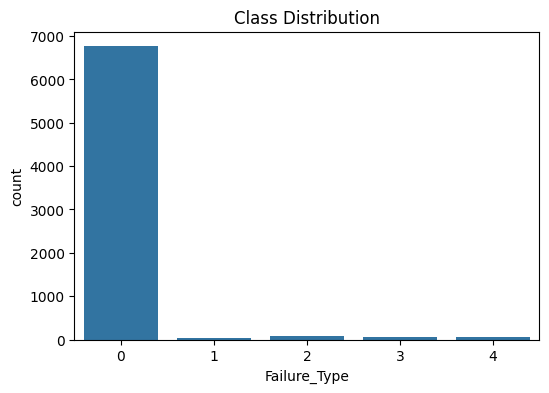

Class Counts:
 Failure_Type
0    6762
2      76
4      69
3      56
1      30
Name: count, dtype: int64

Class Percentage (%):
 Failure_Type
0    96.70
2     1.09
4     0.99
3     0.80
1     0.43
Name: proportion, dtype: float64

Insight:
The dataset is highly imbalanced with one dominant class.
Minority failure types have very few samples, making prediction difficult.


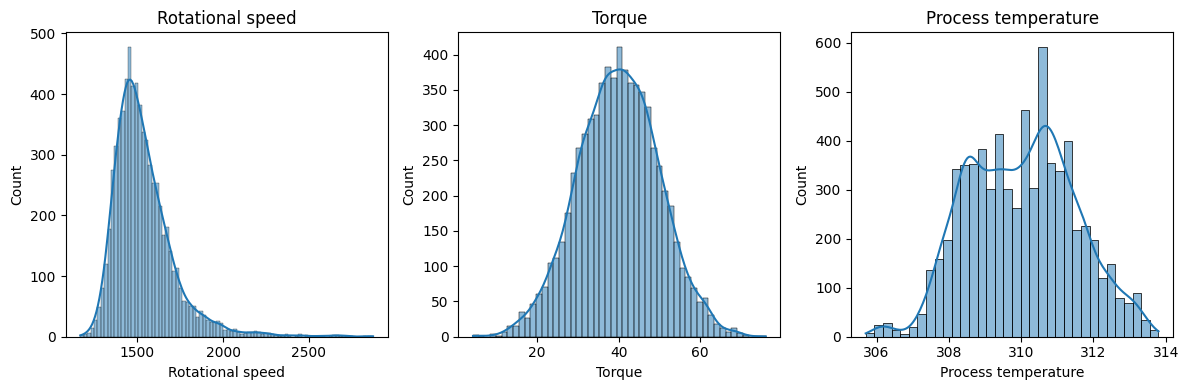


Feature Summary Statistics:
       Rotational speed       Torque  Process temperature
count       6993.000000  6993.000000          6993.000000
mean        1539.017589    39.995796           310.004891
std          179.909994     9.977137             1.481363
min         1168.000000     4.200000           305.700000
25%         1423.000000    33.200000           308.800000
50%         1504.000000    40.100000           310.100000
75%         1614.000000    46.800000           311.100000
max         2874.000000    76.200000           313.800000

Insight:
Rotational speed and Torque show wide variability → strong predictive signals.
Process temperature reflects machine operating conditions.


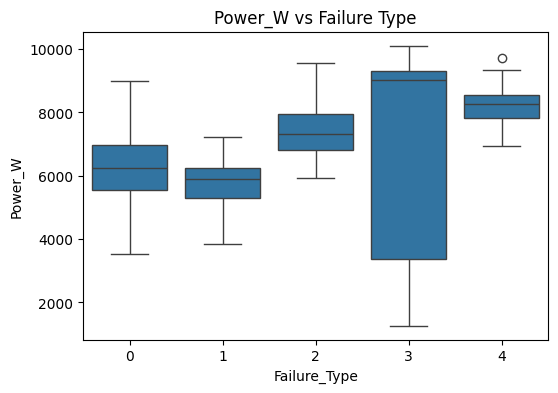

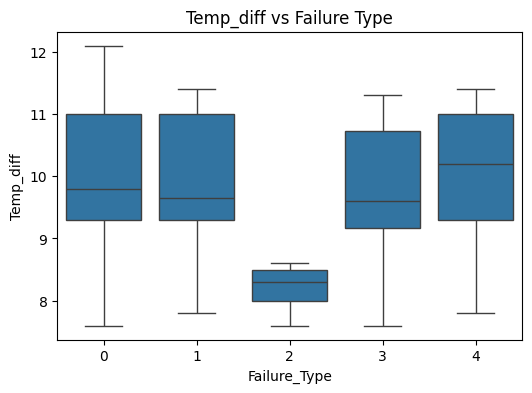


Engineered Feature Grouped Stats:
                  Power_W  Temp_diff
Failure_Type                        
0             6248.240886  10.013812
1             5763.094643   9.966667
2             7403.545453   8.228947
3             6664.382233   9.823214
4             8216.074774  10.072464

Insight:
Power_W captures mechanical stress and varies across failure types.
Temp_diff highlights thermal imbalance, useful for failure prediction.


In [44]:
# Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Failure_Type", data=train)
plt.title("Class Distribution")
plt.savefig("class_distribution.png")
plt.show()

# Show actual data
class_counts = train["Failure_Type"].value_counts()
class_percent = train["Failure_Type"].value_counts(normalize=True) * 100

print("Class Counts:\n", class_counts)
print("\nClass Percentage (%):\n", class_percent.round(2))

print("\nInsight:")
print("The dataset is highly imbalanced with one dominant class.")
print("Minority failure types have very few samples, making prediction difficult.")


# --- Feature Distributions ---
plt.figure(figsize=(12,4))
for i, col in enumerate(["Rotational speed","Torque","Process temperature"],1):
    plt.subplot(1,3,i)
    sns.histplot(train[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.savefig("eda_distributions.png")
plt.show()

# Show summary statistics
print("\nFeature Summary Statistics:")
print(train[["Rotational speed","Torque","Process temperature"]].describe())

print("\nInsight:")
print("Rotational speed and Torque show wide variability → strong predictive signals.")
print("Process temperature reflects machine operating conditions.")


# --- Engineered Feature Analysis (Important) ---
plt.figure(figsize=(6,4))
sns.boxplot(x="Failure_Type", y="Power_W", data=train)
plt.title("Power_W vs Failure Type")
plt.savefig("power_vs_failure.png")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Failure_Type", y="Temp_diff", data=train)
plt.title("Temp_diff vs Failure Type")
plt.savefig("tempdiff_vs_failure.png")
plt.show()

# Show grouped stats
print("\nEngineered Feature Grouped Stats:")
print(train.groupby("Failure_Type")[["Power_W","Temp_diff"]].mean())

print("\nInsight:")
print("Power_W captures mechanical stress and varies across failure types.")
print("Temp_diff highlights thermal imbalance, useful for failure prediction.")

### FEATURE ENGINEERING
Add physics-based features. Improves model interpretability and performance.

In [43]:
def engineer(df):
    df = df.copy()
    df["Power_W"] = df["Torque"] * (df["Rotational speed"] * 2 * np.pi / 60)
    df["Temp_diff"] = df["Process temperature"] - df["Air temperature"]
    return df

train = engineer(train)
current = engineer(current)
stress = engineer(stress)


# --- Show Sample Data ---
print("Sample Data with Engineered Features:")
print(train[["Torque","Rotational speed","Power_W","Temp_diff"]].head())


# --- Summary Statistics ---
print("\nEngineered Feature Statistics:")
print(train[["Power_W","Temp_diff"]].describe())


# --- Grouped Analysis ---
print("\nGrouped Mean by Failure Type:")
print(train.groupby("Failure_Type")[["Power_W","Temp_diff"]].mean())


# --- Insights ---
print("\nInsight:")
print("Power_W represents mechanical stress by combining Torque and Rotational speed.")
print("Higher Power_W values are associated with certain failure types.")
print("Temp_diff captures thermal imbalance between process and air temperature.")
print("Variation in Temp_diff helps distinguish different machine conditions.")

Sample Data with Engineered Features:
   Torque  Rotational speed      Power_W  Temp_diff
0    38.8            1499.0  6090.626621        8.6
1    46.7            1469.0  7184.016057       11.1
2    42.0            1504.0  6614.937491       11.2
3    27.7            1803.0  5230.029202        9.9
4    53.1            1387.0  7712.578549       10.0

Engineered Feature Statistics:
            Power_W    Temp_diff
count   6993.000000  6993.000000
mean    6281.464568     9.993265
std     1067.209431     1.000721
min     1264.051220     7.600000
25%     5561.770914     9.200000
50%     6266.890913     9.800000
75%     7013.417104    11.000000
max    10112.074658    12.100000

Grouped Mean by Failure Type:
                  Power_W  Temp_diff
Failure_Type                        
0             6248.240886  10.013812
1             5763.094643   9.966667
2             7403.545453   8.228947
3             6664.382233   9.823214
4             8216.074774  10.072464

Insight:
Power_W represents me

### ENCODING

Convert categorical feature to numeric. Required for ML models and ensures consistency.

In [35]:
le = LabelEncoder()
train["Type"] = le.fit_transform(train["Type"])
current["Type"] = le.transform(current["Type"])
stress["Type"] = le.transform(stress["Type"])

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

### TRAIN-VALIDATION SPLIT + SMOTE
Handle imbalance correctly. Avoids data leakage and improves minority class learning.

In [36]:
X = train.drop("Failure_Type", axis=1)
y = train["Failure_Type"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

sm = SMOTE(k_neighbors=3, random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)

### MODEL TRAINING + MLFLOW
Train and compare multiple models. Select best model using macro F1 (not accuracy).

In [37]:
models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="mlogloss")
}

results = []

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_res, y_res)
        preds = model.predict(X_val)

        f1 = f1_score(y_val, preds, average="macro")
        report = classification_report(y_val, preds, output_dict=True)

        mlflow.log_param("model", name)
        mlflow.log_metric("macro_f1", f1)

        for cls, vals in report.items():
            if isinstance(vals, dict):
                mlflow.log_metric(f"{cls}_f1", vals["f1-score"])

        results.append((name, f1, model))

best_name, best_f1, best_model = sorted(results, key=lambda x: x[1], reverse=True)[0]
print("Best model:", best_name, best_f1)

Best model: XGBoost 0.736929411591659


### OPTUNA TUNING
Optimize best model hyperparameters. Improves performance systematically.

In [38]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3)
    }
    model = XGBClassifier(**params, eval_metric="mlogloss")
    model.fit(X_res, y_res)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average="macro")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

final_model = XGBClassifier(**study.best_params, eval_metric="mlogloss")
final_model.fit(X_res, y_res)

with mlflow.start_run():
    mlflow.sklearn.log_model(final_model, "model")

joblib.dump(final_model, "best_model.pkl")

[I 2026-04-23 18:39:22,186] A new study created in memory with name: no-name-ad906cc8-27bf-4b00-8993-c333e3f094d0
[I 2026-04-23 18:39:25,607] Trial 0 finished with value: 0.743964477904015 and parameters: {'n_estimators': 145, 'max_depth': 9, 'learning_rate': 0.09306195640657039}. Best is trial 0 with value: 0.743964477904015.
[I 2026-04-23 18:39:26,965] Trial 1 finished with value: 0.73792045463133 and parameters: {'n_estimators': 171, 'max_depth': 9, 'learning_rate': 0.27955054192024703}. Best is trial 0 with value: 0.743964477904015.
[I 2026-04-23 18:39:29,746] Trial 2 finished with value: 0.7305871212979966 and parameters: {'n_estimators': 172, 'max_depth': 7, 'learning_rate': 0.2891168469985174}. Best is trial 0 with value: 0.743964477904015.
[I 2026-04-23 18:39:30,580] Trial 3 finished with value: 0.7437401972447089 and parameters: {'n_estimators': 50, 'max_depth': 9, 'learning_rate': 0.12305341786087083}. Best is trial 0 with value: 0.743964477904015.
[I 2026-04-23 18:39:31,590]

['best_model.pkl']

### DRIFT DETECTION
Detect distribution changes in new data. Helps decide retraining needs.

In [39]:
def drift_report(ref, curr, name):
    html = "<html><body><h2>Data Drift Report</h2><table border=1>"
    html += "<tr><th>Feature</th><th>p-value</th><th>Drift</th></tr>"

    for col in ref.columns:
        stat, p = ks_2samp(ref[col], curr[col])
        drift = "Yes" if p < 0.05 else "No"
        html += f"<tr><td>{col}</td><td>{p:.5f}</td><td>{drift}</td></tr>"

    html += "</table></body></html>"

    with open(name, "w") as f:
        f.write(html)

cols = X_train.columns

drift_report(X_train, current[cols], "drift_current.html")
drift_report(X_train, stress[cols], "drift_stress.html")

### SHAP EXPLAINABILITY
Interpret model predictions. Understand feature impact per failure type.

In [40]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val)

plt.figure(figsize=(12,8))
shap.summary_plot(shap_values, X_val, show=False)
plt.savefig("shap_per_class.png")
plt.close()

<Figure size 1200x800 with 0 Axes>

### COMPLETION
Confirm pipeline execution. Ensures all outputs are generated.

In [41]:
print("Pipeline Completed Successfully")

Pipeline Completed Successfully
